In [1]:
# from jax.lib import xla_bridge
# import jax
# print(xla_bridge.get_backend().platform)
# # name = "cuDNN"
# jax._src.lib.cuda_versions.cudnn_get_version()
# # jax._src.lib.cuda_versions.cudnn_build_version()
# jax.default_device = jax.devices("gpu")[0]

# # # bp.math.set_platform("cpu")
# import os
# # if bp.math.get_platform() == 'cpu':
# threads = os.cpu_count()//10
# os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=' + str(threads)
# print(os.environ["XLA_FLAGS"])

In [2]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Parameterizing by mass means the balance condition is independent of sigma
# zeta_e = (delta*omega_ie)/(gamma*omega_ee)
# zeta_i = (delta*omega_ii)/(gamma*omega_ei)

# * If delta == gamma (population size exactly balanced by synaptic weight), zeta balance
#   reduces to omega_ie == omega_ee and omega_ii == omega_ei

N_e = 30000
J_e = 0.0008 # Microsiemens
delta = 2.0 # 2.9
nu = 10 # Preserve; the minimum required for spontaneous spiking
n_ext = 32

omega_ee = 0.004
omega_ie = 0.016
omega_ei = 0.008
omega_ii = 0.020

In [4]:
from src.models.FNS import FNS
import line_profiler

def build():
        FNSnet = FNS(N_e = N_e,
                J_e = J_e,
                nu = nu,
                n_ext = n_ext,
                delta=delta,
                omega_ee=omega_ee,
                omega_ei=omega_ei,
                omega_ie=omega_ie,
                omega_ii=omega_ii,
                key=jax.random.PRNGKey(42))
        return FNSnet

FNSnet = build()

# %load_ext line_profiler
# %lprun -f FNSnet.__init__ build()

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [5]:
print("Num. Exc.:");print(np.prod(FNSnet.E.size))
print("Num. Inh.:");print(np.prod(FNSnet.I.size))
thr_e, thr_i = FNSnet.nu_next_thresh()
print("Thresholds:");print(thr_e, thr_i)


Num. Exc.:
30000
Num. Inh.:
7500


AttributeError: 'FNS' object has no attribute 'nu_next_thresh'

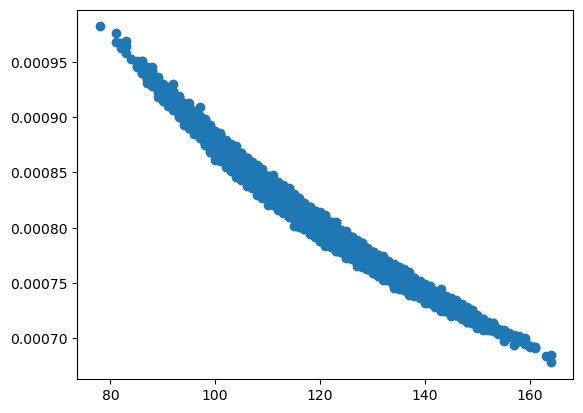

In [ ]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
N = FNSnet.E2E.proj.post.size
ks = src.utils.indegrees_static(FNSnet.E2E.proj.comm.indices, N)
plt.scatter(ks, mean_ws)
# a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
# sks = np.sort(ks)
# plt.plot(sks, a/np.sqrt(sks) + b, 'r')
# plt.xlabel('In-degree')
# plt.ylabel('Mean weight')
# plt.title('Mean weight vs. in-degree')
# plt.show()


# k = src.utils.indegree(FNSnet.E2E.proj)
# k_hat = FNSnet.expected_indegree("ee")
# print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
# k = src.utils.indegree(FNSnet.E2I.proj)
# k_hat = FNSnet.expected_indegree("ei")
# print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
# k = src.utils.indegree(FNSnet.I2E.proj)
# k_hat = FNSnet.expected_indegree("ie")
# print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
# k = src.utils.indegree(FNSnet.I2I.proj)
# k_hat = FNSnet.expected_indegree("ii")
# print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")

# # Print the mean number of external synapses
# k_ext = src.utils.indegree(FNSnet.ext2E.proj)
# print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
# k_ext = src.utils.indegree(FNSnet.ext2I.proj)
# print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")

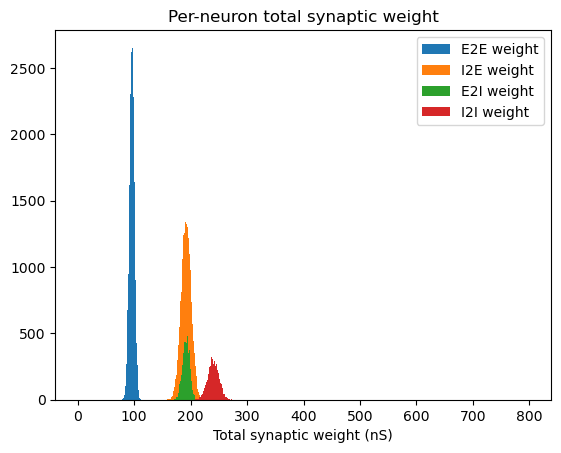

Sum of weights to average neuron:
E2E: 95.99468904622675 (nS)
E2I: 192.0077762251099 (nS)
I2E: 191.9990440381419 (nS)
I2I: 240.02016583145596 (nS)

IE ratio (Exc.): 2.000100692504809
IE ratio (Inh.): 1.2500544017032744

Expected IE ratio (Exc.): 2.0
Expected IE ratio (Inh.): 1.25


Array([0.00075037, 0.00082312, 0.0008212 , ..., 0.00085566, 0.00086076,
       0.00075976], dtype=float32)

In [ ]:
# * Calculate the per-neuron EI balance
# DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
# ? How to peroperly check the balance of weights?
I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
E2I = bp.connect.csr2coo((FNSnet.E2I.proj.comm.indices, FNSnet.E2I.proj.comm.indptr))
I2I = bp.connect.csr2coo((FNSnet.I2I.proj.comm.indices, FNSnet.I2I.proj.comm.indptr))
w_I2E = FNSnet.I2E.proj.comm.weight
w_E2E = FNSnet.E2E.proj.comm.weight
w_E2I = FNSnet.E2I.proj.comm.weight
w_I2I = FNSnet.I2I.proj.comm.weight
assert len(I2E[0]) == len(w_I2E)

Ne = np.prod(FNSnet.E.size)
Ni = np.prod(FNSnet.I.size)
bin_w_E2E = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
bin_w_I2E = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
bin_w_E2I = np.bincount(E2I[1], weights=w_E2I, minlength=Ni)
bin_w_I2I = np.bincount(I2I[1], weights=w_I2I, minlength=Ni)
bins = np.arange(0, 800, 1)
plt.hist(bin_w_E2E*1000, bins=bins, label="E2E weight")
plt.hist(bin_w_I2E*1000, bins=bins, label="I2E weight")
plt.hist(bin_w_E2I*1000, bins=bins, label="E2I weight")
plt.hist(bin_w_I2I*1000, bins=bins, label="I2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_E2E, bin_w_I2E)
# plt.show()

# plt.hist(bin_w_E2E/bin_w_I2E, bins=50)
# plt.show()

# * Print sum of weights in table
print("Sum of weights to average neuron:")
print("E2E:", np.mean(bin_w_E2E)*1000, "(nS)") # Should be approx 2100
print("E2I:", np.mean(bin_w_E2I)*1000, "(nS)") # approx 3800
print("I2E:", np.mean(bin_w_I2E)*1000, "(nS)") # 5800
print("I2I:", np.mean(bin_w_I2I)*1000, "(nS)") # 8100

# * Calculate an IE ratio for each population defined as the ratio of average total incoming
#   inhibitory synaptic strength to average total incoming excitatory synaptic strength for
#   a specific neuron type
print("")
IE_e, IE_i = FNSnet.calculate_zeta()
print("IE ratio (Exc.):", IE_e)
print("IE ratio (Inh.):", IE_i)

print("")
IE_e_hat, IE_i_hat = FNSnet.expected_zeta()
print("Expected IE ratio (Exc.):", IE_e_hat)
print("Expected IE ratio (Inh.):", IE_i_hat)
w_E2E

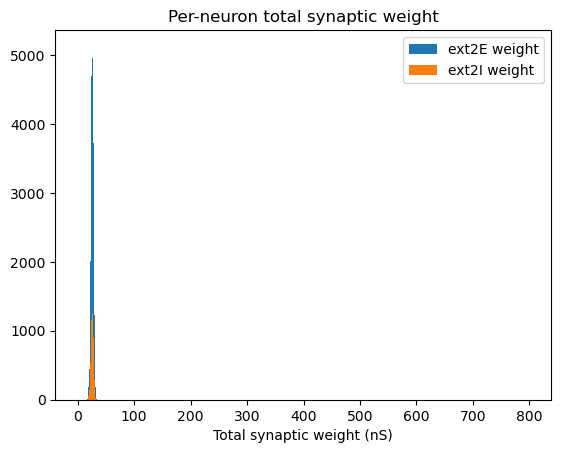

Sum of weights to average neuron (from external):
ext2E: 25.58548744854052 (nS)
ext2I: 25.50586443153831 (nS)


In [ ]:
# * As previous cell, but for external pop
ext2E = bp.connect.csr2coo((FNSnet.ext2E.proj.comm.indices, FNSnet.ext2E.proj.comm.indptr))
ext2I = bp.connect.csr2coo((FNSnet.ext2I.proj.comm.indices, FNSnet.ext2I.proj.comm.indptr))
w_ext2E = FNSnet.ext2E.proj.comm.weight
w_ext2I = FNSnet.ext2I.proj.comm.weight
assert len(ext2E[0]) == len(w_ext2E)

bin_w_ext2E = np.bincount(ext2E[1], weights=w_ext2E, minlength=Ne)
bin_w_ext2I = np.bincount(ext2I[1], weights=w_ext2I, minlength=Ni)
plt.hist(bin_w_ext2E*1000, bins=bins, label="ext2E weight")
plt.hist(bin_w_ext2I*1000, bins=bins, label="ext2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_ext2E, bin_w_ext2I)
# plt.show()

# plt.hist(bin_w_ext2E/bin_w_ext2I, bins=50)
# plt.show()

print("Sum of weights to average neuron (from external):")
print("ext2E:", np.mean(bin_w_ext2E)*1000, "(nS)") # Should be approx 1000
print("ext2I:", np.mean(bin_w_ext2I)*1000, "(nS)") # approx 1000


In [ ]:
# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights
bp.reset_state(FNSnet)
# * Simulate
# I = np.array(FNSnet.E.V.value)
# I[:] = 0.0
# i = I.reshape(*FNSnet.E.size)
# i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike', 'E.g_K', 'I.g_K','E.input', 'I.input'])# , inputs = [('Ein.input', I)])
runner.run(duration=4000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 40000 steps: : 100%|██████████| 40000/40000 [00:17<00:00, 2301.66it/s]


In [ ]:
def plot_trace_with_distribution(runner, neuron_idx=0, pop_type='E', n_bins=50, dt=25.0, figsize=(12, 6), cmap='binary'):
    """
    Plot a single neuron's voltage trace with a histogram distribution at each time step in the background.
    Uses JAX for fast histogram computation with temporal binning.

    Parameters:
    -----------
    runner : bp.DSRunner
        The runner object after simulation
    neuron_idx : int
        Index of the neuron to highlight with a trace
    pop_type : str
        'E' for excitatory neurons or 'I' for inhibitory neurons
    n_bins : int
        Number of voltage bins for the histogram
    dt : float
        Time bin size in ms - data points within this window will be combined
    figsize : tuple
        Size of the figure
    cmap : str
        Colormap for the histogram
    """
    import matplotlib.pyplot as plt
    import jax
    import jax.numpy as jnp
    import numpy as np

    fig, ax = plt.subplots(figsize=figsize)

    # Get the right population data and convert to JAX array
    if pop_type == 'E':
        V_full = jnp.asarray(runner.mon['E.V'])  # Shape should be (time_steps, n_neurons)
        title = f"Distribution of Excitatory Population Voltages (neuron #{neuron_idx} highlighted)"
    else:
        V_full = jnp.asarray(runner.mon['I.V'])  # For inhibitory population
        title = f"Distribution of Inhibitory Population Voltages (neuron #{neuron_idx} highlighted)"

    # Time points
    t_full = jnp.asarray(runner.mon.ts)

    # Apply temporal binning
    if dt > (t_full[1] - t_full[0]):
        # Calculate number of time points per bin
        points_per_bin = int(dt / (t_full[1] - t_full[0]))

        # Calculate number of bins needed
        n_bins_time = len(t_full) // points_per_bin
        if n_bins_time == 0:
            n_bins_time = 1  # At least one bin

        # Reshape the voltage data for binning
        # Only take complete bins
        V_reshaped = V_full[:n_bins_time*points_per_bin].reshape(n_bins_time, points_per_bin, -1)

        # Average within each time bin
        V = jnp.mean(V_reshaped, axis=1)

        # Create new time array with bin centers
        t_edges = t_full[:n_bins_time*points_per_bin:points_per_bin]
        if len(t_edges) > 1:
            bin_width = t_edges[1] - t_edges[0]
            t = t_edges + bin_width/2
        else:
            t = t_edges
    else:
        # No temporal binning needed
        V = V_full
        t = t_full

    # Find voltage range for consistent binning across all time steps
    v_min, v_max = jnp.min(V), jnp.max(V)
    bins = jnp.linspace(v_min, v_max, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Define JAX-compatible histogram function
    @jax.jit
    def compute_histogram(voltages):
        # Convert voltages to bin indices
        indices = jnp.clip(jnp.floor((voltages - v_min) / (v_max - v_min) * n_bins).astype(jnp.int32), 0, n_bins-1)
        # Count occurrences in each bin
        counts = jnp.zeros(n_bins, dtype=jnp.int32)
        counts = counts.at[indices].add(1)
        return counts

    # Vectorize the histogram computation over time steps
    compute_histograms = jax.vmap(compute_histogram)

    # Compute histograms for all time steps at once
    hist_data = compute_histograms(V)

    # Normalize each histogram row for better visibility
    hist_max = jnp.max(hist_data, axis=1, keepdims=True)
    hist_max = jnp.where(hist_max == 0, 1.0, hist_max)  # Avoid division by zero
    hist_norm = hist_data / hist_max

    # Convert back to numpy for matplotlib
    hist_norm = jnp.transpose(hist_norm).block_until_ready()

    # Plot the distribution over time as a 2D histogram/heatmap
    im = ax.pcolormesh(
        t,
        bin_centers,
        hist_norm,
        cmap=cmap,
        alpha=0.7
    )

    # Plot single neuron trace on top - use original high-resolution data for the trace
    ax.plot(t_full, V_full[:, neuron_idx], color='red', lw=1.5, label=f'Neuron {neuron_idx}')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Normalized Neuron Count')

    # Set labels and title
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane Potential (mV)')
    ax.set_title(f"{title} [dt={dt}ms]")
    ax.legend(loc='lower right')

    plt.tight_layout()
    return fig

Steady-state membrane potential (Exc.): -63.56167664670659
Steady-state membrane potential (Inh.): -65.6992
Mean membrane potential (Exc.): -62.848682
Mean membrane potential (Inh.): -65.055916


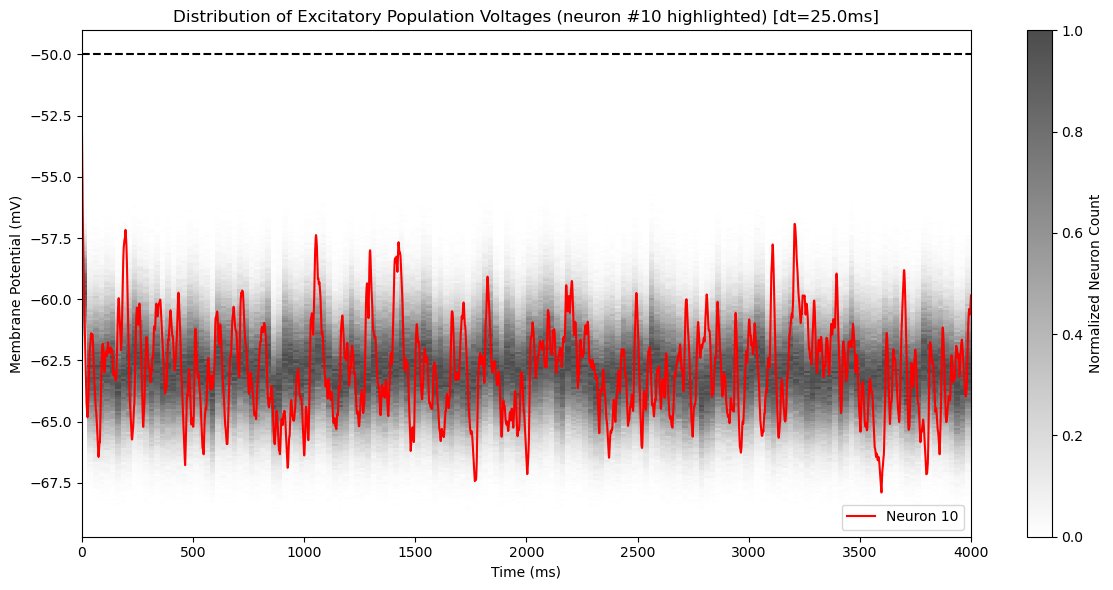

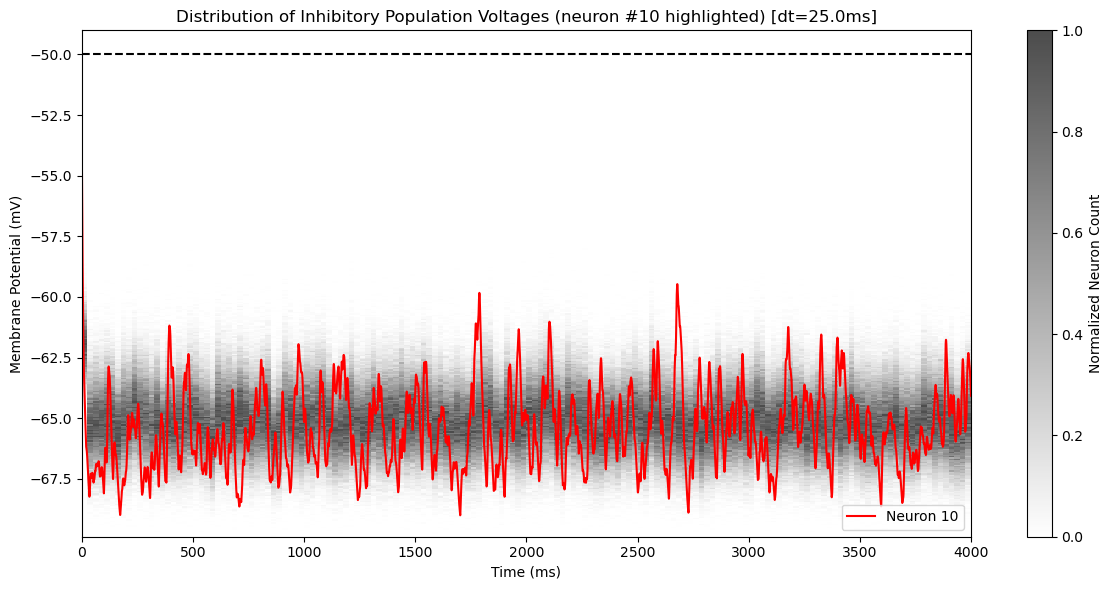

In [ ]:
ve, vi = FNSnet.steady_state_membrane_potential()
print("Steady-state membrane potential (Exc.):", ve)
print("Steady-state membrane potential (Inh.):", vi)
mve = np.mean(runner.mon['E.V'])
mvi = np.mean(runner.mon['I.V'])
print("Mean membrane potential (Exc.):", mve)
print("Mean membrane potential (Inh.):", mvi)

# Plot the distribution over time for excitatory population with neuron #10 highlighted
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='E', n_bins=200)
thr_e = FNSnet.E.V_th
plt.axhline(thr_e, color='black', linestyle='--', lw=1.5)
# Add dashed lines showing threshold

# Plot for inhibitory population
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='I', n_bins=200)
thr_i = FNSnet.I.V_th
plt.axhline(thr_i, color='black', linestyle='--', lw=1.5)


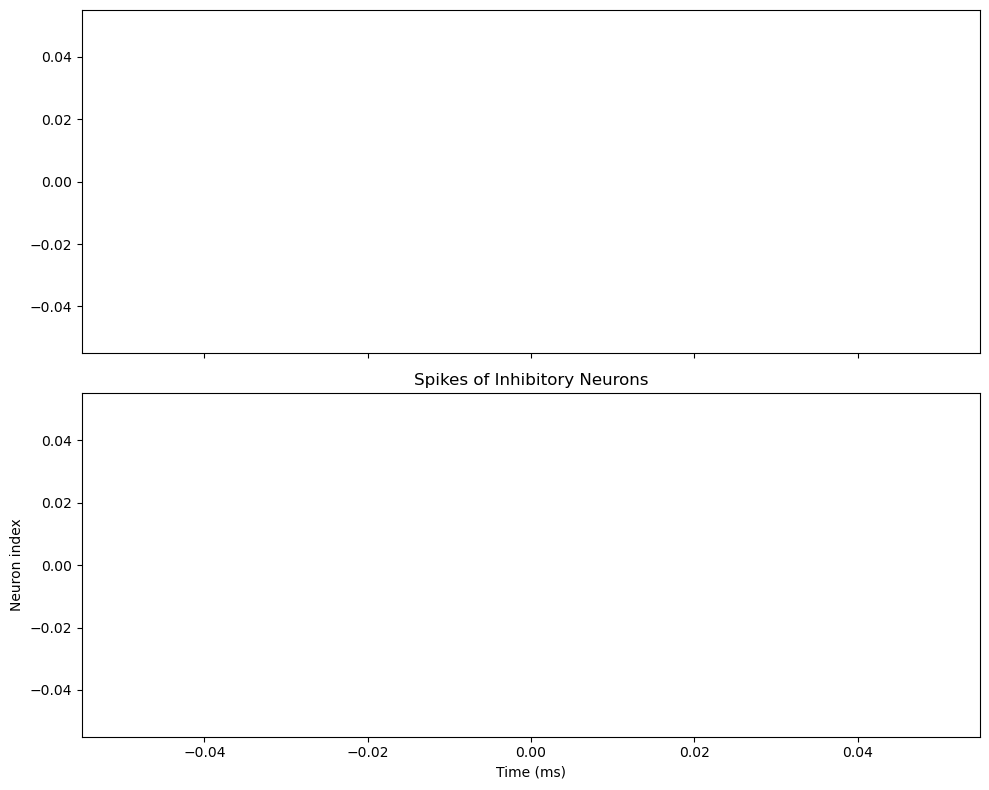

In [ ]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::50],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
plt.show()

In [ ]:

C = FNSnet.E.C
g_L = FNSnet.E.g_L
tau_d = FNSnet.ext2E.tau_d
tau_r = FNSnet.ext2E.tau_r
V_rev = FNSnet.ext2E.V_rev
V_L = FNSnet.E.V_L

tau_m = C/g_L
alpha = tau_d * tau_m**2 / ((tau_m + tau_d)*(tau_m + tau_r)) * (tau_r/tau_d)**(tau_r/(tau_r - tau_d))
alpha = alpha * (V_rev - V_L)

print(tau_m)
print(tau_d)
print(alpha)

14.970059880239521
5.0
367.7661123230758


In [ ]:
FNSnet.estimate_filter_factor('E')